In [11]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


## Coverage with accuracy

In [12]:
# load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = "post_processed_0-39_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v070726_v080726_geo"
#"post_processed_labelled_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v300626_v300626_geo"
# "post_processed_0-39_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v070726_v080726_geo"


# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_all_v30062026_v300626_geo"  # merged_subtypes_

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
# load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
# load corresponding matched data
ws_key_qt = "ws_quanti_opt"
ws_key_ql = "ws_quali_opt"
filename_match = f"matched_data_by_labelled_{ws_key_qt}qt-{ws_key_ql}ql-geo-valuepre-loose-nans_{res_savename_ext}"
# f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = []
#drop_appeals = [
#   "MDRCO023",
#   "MDRGW003",
#   "MDRHU005",
#   "MDRPH021",
#   "MDRRS015",
#   "MDRMN017",
#   "MDRGT009",
#   "MDRPG008",
#   "MDREC019",
#   "MDRTN010",
#   "MDRCR012",
#   "MDRGE019",]

keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

# compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [13]:
matched_df.appealCode.nunique()

39

In [14]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                133
Residential Buildings                          124
Agriculture and Access to Food                  66
Human Deaths                                    49
Transportation                                  44
Water, Sanitation, and Hygiene                  44
Displaced People                                41
Economy and Livelihood                          37
Undefined Infrastructure and Service Access     33
DREF Allocation & Funding requirements          26
Infected and Ill People                         26
Injured People                                  25
Healthcare                                      22
Education                                       18
Human Health and Wellbeing                      14
Assisted People                                 13
Targeted People                                 11
Informal Settlements                            10
Missing People                                   9
Homeless People  

In [15]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                151
Residential Buildings                          117
Agriculture and Access to Food                 104
Water, Sanitation, and Hygiene                  71
DREF Allocation & Funding requirements          67
Displaced People                                50
Human Deaths                                    49
Assisted People                                 48
Economy and Livelihood                          48
Targeted People                                 45
Transportation                                  37
Healthcare                                      36
Homeless People                                 29
Human Health and Wellbeing                      28
Infected and Ill People                         26
Injured People                                  25
Education                                       17
Missing People                                   9
Informal Settlements                             7
Undefined Infrast

In [ ]:
## add other variables useful for analysis
# report type
file_path = (
    DATA_IN_JSONS
    / "preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326.csv"
)  #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')
labelled_reports_raw["reportSize"] = labelled_reports_raw["nathaz_text"].apply(len)


# add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])

In [19]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)

/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [20]:
from src.sanity_checks import flag_remove_cat
#remove_cats = [
#    "Unknown",
#    "DREF Allocation & Funding requirements",
#    "Targeted People",
#    "Assisted People",
#    "Other Human Impacts",
#    "Other Infrastructural Impacts",
#    "Other Agricultural Impacts",
#    "Other Service Access Impacts",
#]  # "Human Health and Wellbeing", "Economy and Livelihood"
#extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
#labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
#matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [21]:
# define threshold above which we consider a match

value_error_th = 0.05
sim_th = 0.5
match_cats_quali = ["impactSubtype"]
filter_flags = [
    "flag_remove_cat",
    "flag_unit_nonstd",
    "flag_percent",
    "flag_remove_unit",
    "flag_unit_nonstd",
    #"flag_value_no_unit",
]  # ["flag_unit_nonstd"
keep_vars = ["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th, match_cat=match_cats_quali)
missed_df = labelled_df_filter[~labelled_df_filter.index.isin(matched_df_filter2["lab_match_id_sim"])]
# add report size to missed_df

false_positives_df = extracted_df_filter[~extracted_df_filter.index.isin(matched_df_filter2["ext_match_id_sim"])]
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [22]:
missed_df.appealCode.value_counts()

appealCode
MDRYE011    22
MDRUG050    16
MDRPK018    16
MDRKE058    14
MDRBJ019    12
MDRSD034    12
MDRRS015    11
MDRCM036     7
MDRLB013     7
MDRSV012     6
MDRPH036     5
MDRNG041     5
MDRRW022     5
MDRS2001     4
MDRDZ011     4
MDRPK026     4
MDRJO003     3
MDRBD022     3
MDRMZ024     3
MDRIQ014     2
MDRUY004     2
MDRVU012     2
MDRCM039     1
MDRMY003     1
MDRZM022     1
MDRMN017     1
MDREC019     1
MDRTJ035     1
MDRAF014     1
MDRKZ010     1
MDRID013     1
MDRIR009     1
Name: count, dtype: int64

In [23]:
missed_df.impactSubtype.value_counts()

impactSubtype
Affected People                                40
Residential Buildings                          28
Undefined Infrastructure and Service Access    21
Infected and Ill People                        15
Human Deaths                                   12
Transportation                                  9
Agriculture and Access to Food                  9
Displaced People                                7
Economy and Livelihood                          6
Healthcare                                      4
Education                                       4
Injured People                                  4
Unknown                                         4
Water, Sanitation, and Hygiene                  3
Homeless People                                 2
Human Health and Wellbeing                      2
Power and Energy Production                     2
Informal Settlements                            2
IT and Communication                            1
Name: count, dtype: int64

Text(0, 0.5, 'Report size (characters)')

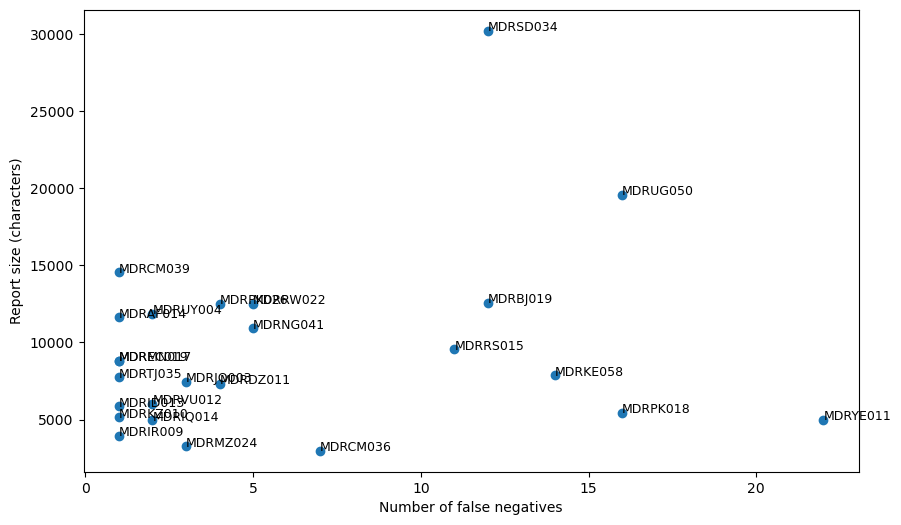

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "appealCode"
ykey = "reportSize"
x = missed_df.groupby("appealCode")[xkey].count()
y = missed_df.groupby("appealCode").head(1).set_index("appealCode")[ykey]
plot_df = pd.DataFrame(
    {
        "x": x,
        "y": y,
    }
)

ax.plot(plot_df["x"], plot_df["y"], "o")

for appeal, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], appeal, fontsize=9)

ax.set_xlabel("Number of false negatives")
ax.set_ylabel("Report size (characters)")

In [25]:
false_positives_df.appealCode.value_counts()

appealCode
MDRSD034    33
MDRKE058    25
MDRUG050    24
MDRRW022    17
MDRCO023    15
MDRYE011    12
MDRUY004    10
MDRBJ019    10
MDRPK018    10
MDRPH036    10
MDRZM022     9
MDRDZ011     9
MDRNG041     9
MDRVU012     8
MDRAF014     8
MDRPG008     7
MDRCM039     7
MDRLB013     7
MDRCM036     7
MDRRS015     6
MDRIQ014     6
MDRPK026     6
MDRID013     5
MDRIR009     5
MDRMN017     5
MDRJO003     4
MDRS2001     4
MDRTJ035     4
MDRBD022     4
MDREC019     3
MDRKZ010     3
MDR55001     2
MDRSV012     2
MDRMZ024     2
MDRDZ008     1
MDRGW003     1
MDRCN006     1
Name: count, dtype: int64

In [26]:
false_positives_df.groupby("appealCode").count()

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,appealType,reportSize
appealCode,,,,,,,,,,,,,,,,,,,,,
MDR55001,2,0,0,0,0,2,2,2,2,2,...,2,2,2,2,2,0,2,2,0,0
MDRAF014,8,4,0,0,4,8,8,8,8,8,...,8,8,8,8,8,0,8,8,8,8
MDRBD022,4,2,0,0,2,4,4,4,4,4,...,4,4,4,4,4,0,4,4,0,0
MDRBJ019,10,4,0,0,4,10,10,10,10,10,...,10,10,10,10,10,0,10,10,10,10
MDRCM036,7,3,0,0,3,7,7,7,7,7,...,7,7,7,7,7,0,7,7,7,7
MDRCM039,7,1,0,0,1,7,7,7,7,7,...,7,7,7,7,7,0,7,7,7,7
MDRCN006,1,1,0,0,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,0,0
MDRCO023,15,4,0,0,4,15,15,15,15,15,...,15,15,15,15,15,0,15,15,0,0
MDRDZ008,1,1,0,0,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,0,0


In [27]:
330 + 88

418

Text(0, 0.5, 'Report size (characters)')

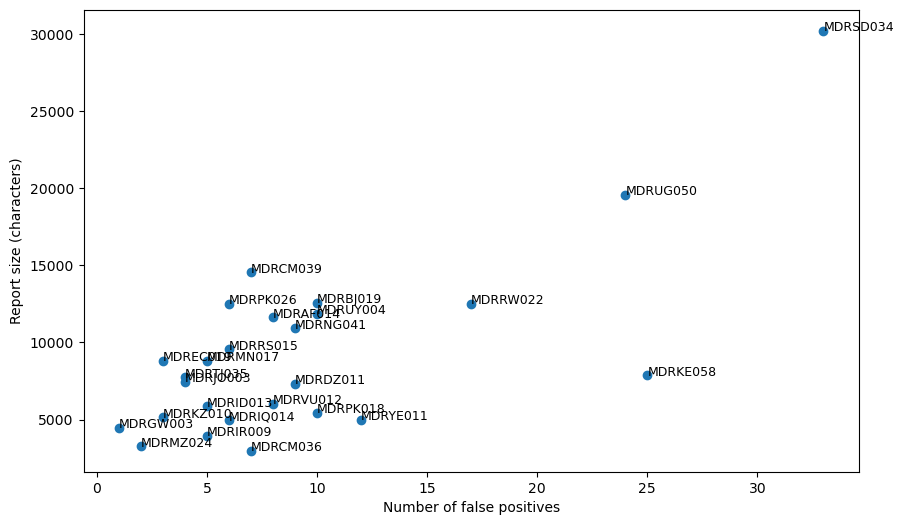

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "appealCode"
ykey = "reportSize"
x = false_positives_df.groupby("appealCode")[xkey].count()
y = false_positives_df.groupby("appealCode").head(1).set_index("appealCode")[ykey]
plot_df = pd.DataFrame(
    {
        "x": x,
        "y": y,
    }
)

ax.plot(plot_df["x"], plot_df["y"], "o")

for appeal, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], appeal, fontsize=9)

ax.set_xlabel("Number of false positives")
ax.set_ylabel("Report size (characters)")

/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: title={'center': 'False positives and negatives by flag'}>

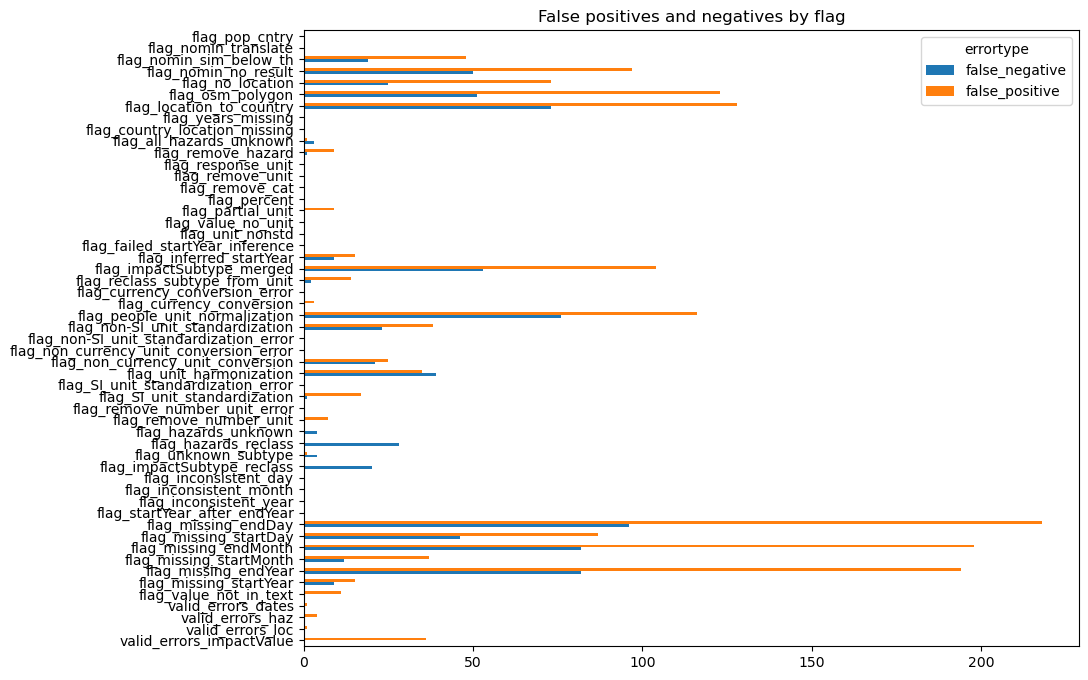

In [74]:
# flag analysis
false_positives_df["errortype"] = "false_positive"
missed_df["errortype"] = "false_negative"
false_and_missed = pd.concat([false_positives_df, missed_df], axis=0)
flag_cols = [
    col
    for col in false_and_missed.columns
    if col.startswith("flag_") or col.startswith("valid_")
]
def normalize_flags(x):
    if pd.isna(x):
        return np.nan
    elif x in [0, 0.0, "0", "0.0"]:
        return 0
    elif x in [1, 1.0, "1", "1.0"]:
        return 1
    else:
        return x


false_and_missed[flag_cols] = false_and_missed[flag_cols].map(normalize_flags)

counts = false_and_missed.groupby("errortype")[flag_cols].sum().T

counts.plot(
    kind="barh",
    figsize=(10, 8),
    title="False positives and negatives by flag",
)

<Axes: title={'center': 'False positives and negatives by flag'}>

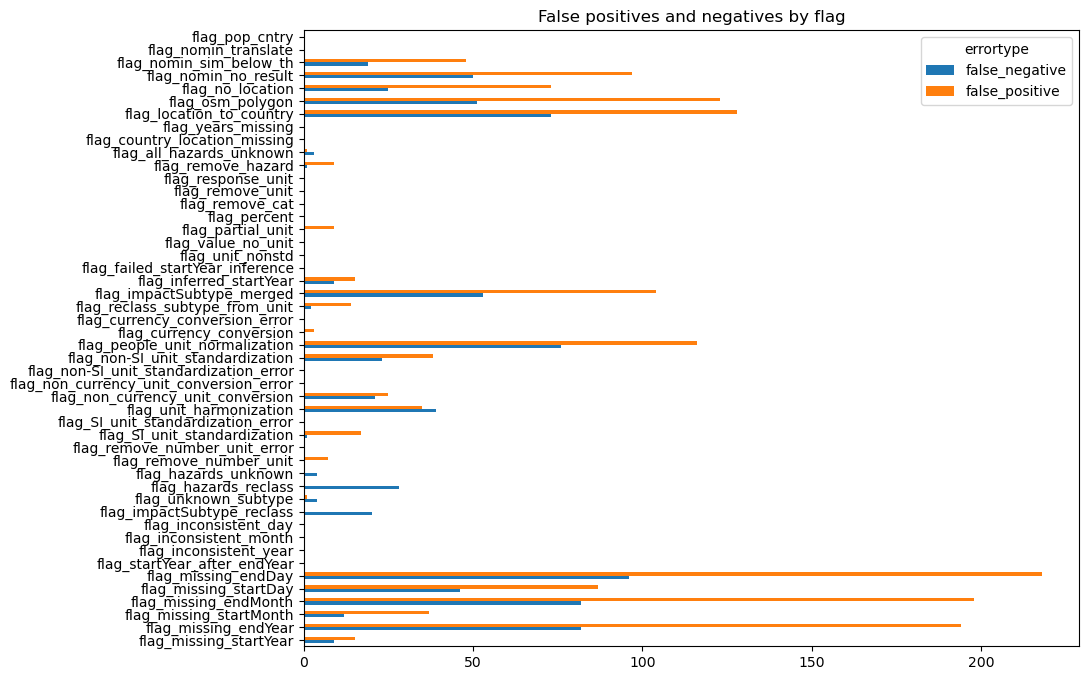

In [76]:
# flag analysis
flag_cols = [
    col
    for col in missed_df.columns
    if col.startswith("flag_") or col.startswith("valid_")
]


def normalize_flags(x):
    if pd.isna(x):
        return np.nan
    elif x in [0, 0.0, "0", "0.0"]:
        return 0
    elif x in [1, 1.0, "1", "1.0"]:
        return 1
    else:
        return x


counts = false_and_missed.groupby("errortype")[flag_cols].sum().T

counts.plot(
    kind="barh",
    figsize=(10, 8),
    title="False positives and negatives by flag",
)

In [29]:
false_positives_df.impactSubtype.value_counts()

impactSubtype
Affected People                                57
Agriculture and Access to Food                 34
Residential Buildings                          30
Water, Sanitation, and Hygiene                 28
Homeless People                                20
Human Health and Wellbeing                     18
Displaced People                               18
Economy and Livelihood                         17
Healthcare                                     15
Human Deaths                                   15
Transportation                                 15
Infected and Ill People                        13
Education                                       6
Informal Settlements                            5
Undefined Infrastructure and Service Access     3
Injured People                                  3
Power and Energy Production                     2
IT and Communication                            1
Unknown                                         1
Name: count, dtype: int64

In [85]:
print_match(matched_df_filter[matched_df_filter["appealCode"] == "MDRSD034"])

NameError: name 'matched_df_filter' is not defined

In [82]:
print_impact(false_positives_df[false_positives_df["appealCode"] == "MDRSD034"])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
215,MDRSD034,Affected People,696000.0,people,['17 states'],['Khartoum'],2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The situation led to with widespread floods ...,['The situation led to with widespread floods ...,"['On 25 August 2024, heavy rains led to widesp...",['There was a notable increase in number of pe...
219,MDRSD034,Affected People,460743.0,people,['15 states'],['Sharg An Neel'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['On 25.08.2024, the data collected indicated ...","['On 25.08.2024, the data collected indicated ...","['On 25.08.2024, the data collected indicated ...","['On 25.08.2024, the data collected indicated ..."
222,MDRSD034,Homeless People,39081.0,people,[],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['The floods resulted on 64 fatalities, 1,246 ...","['The floods resulted on 64 fatalities, 1,246 ...","['The floods resulted on 64 fatalities, 1,246 ...","['The floods resulted on 64 fatalities, 1,246 ..."
225,MDRSD034,Affected People,178460.0,people,"['Northern States', 'River Nile State']","['Northern', 'Baw']",2024.0,8.0,NaN,NaN,NaN,NaN,['Flood'],"['From IOM, rain and floods displaced an estim...","['From IOM, rain and floods displaced an estim...","['From IOM, rain and floods displaced an estim...","['From IOM, rain and floods displaced an estim..."
229,MDRSD034,Homeless People,10000.0,people,"['Northern State', 'Gold locality']","['Northern', 'Sudan']",2024.0,8.0,NaN,NaN,NaN,NaN,['Flood'],"['In Northern state, SRCS rapid assessments in...","['In Northern state, SRCS rapid assessments in...","['On 25 August 2024, heavy rains led to widesp...","['In Northern state, SRCS rapid assessments in..."
233,MDRSD034,"Water, Sanitation, and Hygiene",270.0,structures,[],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['Public infrastructure also suffered greatly,...","['Public infrastructure also suffered greatly,...","['On 25 August 2024, heavy rains led to widesp...","['Public infrastructure also suffered greatly,..."
236,MDRSD034,Transportation,3.0,roads,"['Atbara-Abu Hamad Road', 'Dongola-Halfa Road'...","['Sudan', 'Northern']",2024.0,8.0,NaN,NaN,NaN,NaN,['Flood'],"['In Northern state, SRCS rapid assessments in...","['In Northern state, SRCS rapid assessments in...","['On 25 August 2024, heavy rains led to widesp...","['In Northern state, SRCS rapid assessments in..."
237,MDRSD034,Transportation,1.0,roads,"['Atbara', 'Abu Hamad', 'Dongola', 'Halfa', 'A...","['Reifi Nahr Atbara', 'Atbara', 'Abu Hamad', '...",2024.0,8.0,NaN,NaN,NaN,NaN,['Flood'],"['In Northern state, SRCS rapid assessments in...","['In Northern state, SRCS rapid assessments in...","['On 25 August 2024, heavy rains led to widesp...","['In Northern state, SRCS rapid assessments in..."
240,MDRSD034,Displaced People,185805.0,people,[],['Sudan'],2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Conflict']",['OCHA reports indicates that floods as of Mar...,['OCHA reports indicates that floods as of Mar...,"['On 25 August 2024, heavy rains led to widesp...",['OCHA reports indicates that floods as of Mar...
242,MDRSD034,Residential Buildings,66159.0,homes,"['Red Sea', 'North Darfur', 'White Nile', 'Nor...","['Kassala', 'Red Sea', 'Northern', 'North Darf...",2025.0,3.0,NaN,NaN,NaN,NaN,['Flood'],['OCHA reports indicates that floods as of Mar...,['OCHA reports indicates that floods as of Mar...,"['On 25 August 2024, heavy rains led to widesp...",['OCHA reports indicates that floods as of Mar...


In [84]:
print_impact(missed_df[missed_df["appealCode"] == "MDRSD034"])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,annotation
506,MDRSD034,Undefined Infrastructure and Service Access,NaN,null,[],['Sudan'],2024.0,NaN,NaN,2025.0,3.0,10.0,['Conflict'],['The conflict caused significant damage to in...
507,MDRSD034,Undefined Infrastructure and Service Access,NaN,null,['Arbaat Dam'],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['In total, 119 incidents of heavy rain were r..."
508,MDRSD034,Human Deaths,30.0,people,['Arbaat Dam'],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],"['In total, 119 incidents of heavy rain were r..."
526,MDRSD034,Residential Buildings,2000.0,homes,['Gold Locality'],['Sudan'],2024.0,4.0,NaN,2024.0,10.0,NaN,['Flood'],"['On 25 August 2024, heavy rains led to widesp..."
528,MDRSD034,Residential Buildings,8016.0,homes,['Abu Hamad locality'],['Abu Hamad'],2024.0,4.0,NaN,2024.0,10.0,NaN,['Flood'],"['On 25 August 2024, heavy rains led to widesp..."
529,MDRSD034,Human Deaths,34.0,people,['River Nile State'],['Baw'],2024.0,4.0,NaN,2024.0,10.0,NaN,['Flood'],"['On 25 August 2024, heavy rains led to widesp..."
558,MDRSD034,Infected and Ill People,11014.0,people,['White Nile'],['White Nile'],2024.0,NaN,NaN,2025.0,3.0,10.0,"['Epidemic', 'Flood']",['The cumulative cases jumped from 2895 cases ...
559,MDRSD034,Infected and Ill People,11014.0,people,['Gazira'],['Sudan'],2024.0,NaN,NaN,2025.0,3.0,10.0,"['Epidemic', 'Flood']",['The cumulative cases jumped from 2895 cases ...
561,MDRSD034,Infected and Ill People,7444.0,people,['Kassala'],['Kassala'],2024.0,NaN,NaN,2025.0,3.0,10.0,"['Epidemic', 'Flood']",['The cumulative cases jumped from 2895 cases ...
562,MDRSD034,Infected and Ill People,6123.0,people,['River Nile state'],['Baw'],2024.0,NaN,NaN,2025.0,3.0,10.0,"['Epidemic', 'Flood']",['The cumulative cases jumped from 2895 cases ...


In [33]:
print(extracted_df_filter[
    (extracted_df_filter["appealCode"] == "MDRYE011")
    # & (extracted_df["impactSubtype"] == "Affected People")
]["nathaz_text"].values[0])

["P a g e | 1 Emergency Plan of Action (EPoA) Yemen: Sanaa Floods DREF Operation n° MDRYE011 Glide n°: FL-2022-000265-YEM Date of issue: 29/07/2022 Expected timeframe: 6 months Expected end date: 31/01/2023 Category allocated to the of the disaster or crisis: Orange DREF allocated: CHF 452,156 Total number of people affected: Approximately 76,790 Number of people to 19,509 people (2,787 HH) be assisted: people affected Governorates affected: Marib, Al Mahwit, Governorates targeted: Al Hodeida, Hajjah Taiz, Ibb, Hadramout, and Al- Hadramawt, Al Mahra, Marib and Sana’a Bayda, Amran, Governorates Sadaa, Dhamar Al Hodeida Sana'a Hajjah, Al Mahra governorates Operating National Society: Yemen Red Crescent Society has branches in all 22 Governates of Yemen, with 321 staff and 4,500 active volunteers, including 44 National Disaster Response trained team members, as well as trained first aid volunteers ready to deploy in case of emergency.", 'Red Cross Red Crescent Movement partners: British R

In [34]:
extracted_df_filter[extracted_df_filter["quanti"]=="quali"]["startYear"].value_counts(dropna=False).T

startYear
2024.0    112
2023.0     70
2022.0     23
2021.0     12
2020.0     10
2018.0     10
2019.0      6
2016.0      3
1992.0      1
1985.0      1
Name: count, dtype: int64

In [35]:
print_impact(
    extracted_df_filter[
        (extracted_df_filter["appealCode"] == "MDRSD034")
        #& (extracted_df["impactSubtype"] == "Affected People")
    ]
)

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
212,MDRSD034,Affected People,460743.0,people,[],['Sudan'],2024.0,8.0,25.0,NaN,NaN,NaN,"['Flood', 'Conflict']","['People Affected: 460,743 people']","['People Affected: 460,743 people']","['On 25 August 2024, heavy rains led to widesp...","['On 25 August 2024, heavy rains led to widesp..."
215,MDRSD034,Affected People,696000.0,people,['17 states'],['Khartoum'],2025.0,3.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The situation led to with widespread floods ...,['The situation led to with widespread floods ...,"['On 25 August 2024, heavy rains led to widesp...",['There was a notable increase in number of pe...
216,MDRSD034,Affected People,24800000.0,people,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...
217,MDRSD034,Displaced People,10000000.0,people,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...,['The dual crises of flooding and cholera outb...
218,MDRSD034,Healthcare,80.0,healthcare structures,[],['Sudan'],2023.0,4.0,NaN,NaN,NaN,NaN,"['Conflict', 'Flood', 'Epidemic']",['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,MDRSD034,"Water, Sanitation, and Hygiene",NaN,null,"['Tokar', 'Port Sudan', 'Khor Baraka', 'Khor A...","['Baw', 'Northern', 'Red Sea', 'Tawkar', 'Suda...",2024.0,8.0,25.0,NaN,NaN,NaN,"['Flood', 'Epidemic']",['unsafe drinking water'],['The catastrophic collapse of the Arba’at Dam...,['The catastrophic collapse of the Arba’at Dam...,"['On August 25, the catastrophic collapse of t..."
318,MDRSD034,Homeless People,NaN,null,"['Tokar', 'Atbara-Abu Hamad Road', 'Dongola-Ha...","['Kassala', 'Baw', 'Northern', 'Sudan', 'Abu H...",2024.0,7.0,NaN,2025.0,3.0,10.0,"['Flood', 'Epidemic', 'Conflict']",['These basic necessities will offer comfort a...,['Residents have described the situation in To...,"['On 25 August 2024, heavy rains led to widesp...","['The floods resulted on 64 fatalities, 1,246 ..."
319,MDRSD034,Transportation,NaN,null,"['Atbara-Abu Hamad Road', 'Dongola-Halfa Road'...","['Northern', 'Sudan', 'Abu Hamad', 'Red Sea', ...",2024.0,8.0,25.0,NaN,NaN,NaN,['Flood'],['Flooding from Khor Arab and Khor Baraka furt...,"['In Northern state, SRCS rapid assessments in...","['On August 25, the catastrophic collapse of t...","['On August 25, the catastrophic collapse of t..."
320,MDRSD034,Economy and Livelihood,NaN,null,"['Tokar', 'Port Sudan', 'Aqeeq', 'Khor Baraka'...","['Gedaref', 'Kassala', 'Baw', 'Northern', 'Sud...",2023.0,4.0,NaN,NaN,NaN,NaN,"['Flood', 'Epidemic', 'Conflict']",['This therefore calls for the SRCS to support...,['The waters of Khor Baraka surging in a 6-met...,"['On 25 August 2024, heavy rains led to widesp...",['the conflict that began in April 2023']


In [37]:
extracted_df_filter

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,appealType,reportSize
0,Affected People,2176519.0,NaN,NaN,exact,people,"['Total number of people affected: 2,176,519']",0,[],"['Total number of people affected: 2,176,519']",...,['Bangladesh'],['BGD'],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
3,Displaced People,31818.0,NaN,NaN,exact,people,"['of people who have moved to safe shelter 31,...",0,[],"['of people who have moved to safe shelter 31,...",...,['Bangladesh'],['BGD'],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
4,Residential Buildings,3988.0,NaN,NaN,exact,homes,"['of fully damaged house 3,988']",0,[],"['No. of fully damaged house 3,988']",...,['Bangladesh'],['BGD'],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
5,Residential Buildings,98571.0,NaN,NaN,exact,homes,"['of partially damaged house 98,571']",0,[],"['of partially damaged house 98,571']",...,['Bangladesh'],['BGD'],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
7,Affected People,2100000.0,NaN,NaN,exact,people,['According to National disaster response coor...,0,['21 districts'],['According to National disaster response coor...,...,['Dhaka'],['BGD'],[229.0],[2474],[124259],NaN,False,"MULTIPOLYGON (((90.18576 23.56293, 90.18114 23...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,Human Health and Wellbeing,NaN,NaN,NaN,None,null,['BBC news reported that the snowfall in these...,1,"['Azad Jammu and Kashmir (AJK)', 'Balochistan'...","['In January 2020, several parts of Pakistan w...",...,"['Balochistan', 'Jaffarabad', 'Khyber Pakhtunk...",['PAK'],[260.0],"[2905, 2907, None]","[None, 130104, 130130, 130103, 130112, 130122,...",NaN,False,"MULTIPOLYGON (((69.854 32.09808, 69.85255 32.0...",DREF Operation Final Report,5417.0
975,Transportation,NaN,NaN,NaN,None,null,['Gilgit Baltistan authorities mobilized all t...,0,"['Azad Jammu and Kashmir (AJK)', 'Balochistan'...","['In January 2020, several parts of Pakistan w...",...,"['Balochistan', 'Jaffarabad', 'Khyber Pakhtunk...",['PAK'],[260.0],"[2905, 2907, None, 2909]","[None, 130104, 130206, 130130, 130103, 130112,...",NaN,False,"MULTIPOLYGON (((69.854 32.09808, 69.85255 32.0...",DREF Operation Final Report,5417.0
976,Affected People,2282.0,NaN,NaN,exact,people,['Number of people affected: up to approximate...,0,['Szabolcs-Szatmár-Bereg County'],"['On 21 June 2016, heavy rain and hailstorm hi...",...,['Szabolcs Szatmar Bereg'],['HUN'],[308.0],[3509],[None],NaN,False,"MULTIPOLYGON (((22.23993 48.40959, 22.24112 48...",DREF Operation Final Report,1736.0
978,Residential Buildings,750.0,NaN,NaN,exact,homes,['It was reported by the National Directorate ...,1,['Szabolcs-Szatmár-Bereg County'],"['On 21 June 2016, heavy rain and hailstorm hi...",...,['Szabolcs Szatmar Bereg'],['HUN'],[308.0],[3509],[None],NaN,False,"MULTIPOLYGON (((22.23993 48.40959, 22.24112 48...",DREF Operation Final Report,1736.0


In [38]:
false_positives_df.value_counts("quanti")

quanti
quanti    178
quali     123
Name: count, dtype: int64

In [42]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

14

In [43]:

nboots = 5000
df_list = []
for qq in ["all", "quanti", "quali"]:
    if qq == "all":
        labelled_dfq = labelled_df_filter
        extracted_dfq = extracted_df_filter
        matched_df_filterq = matched_df_filter2
    else:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "n_ext": n_ext,
            "n_lab": n_lab,
            "tps": tps,
            "fps": fps,
            "fns": fns,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [44]:
f1_bs_all[["quanti","f1", "precision", "recall"]]

,quanti,f1,precision,recall
0,all,0.721607,0.696524,0.748563
0,quanti,0.702479,0.680000,0.726496
0,quali,0.794118,0.762097,0.828947


In [45]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_subtype = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [46]:
from src.impact_def import IMPACT_TYPES_MERGED

labelled_df_filter["impactType"] = labelled_df_filter["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
extracted_df_filter["impactType"] = extracted_df_filter["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
matched_df_filter2["impactType"] = matched_df_filter2["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
group_keys = pd.unique(IMPACT_TYPES_MERGED.values())
group_key = "impactType"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_maintype = pd.concat(df_list).reset_index(drop=False, names=[group_key])
# append the total column
tot_col = f1_bs_all[f1_bs_all["quanti"] == "Total"].copy().rename(columns={"quanti": group_key})
f1_bs_by_maintype = pd.concat([tot_col, f1_bs_by_maintype]).reset_index(drop=True)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_14833/654541244.py:12: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  group_keys = pd.unique(IMPACT_TYPES_MERGED.values())


In [47]:
f1_bs_by_maintype

,impactType,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Human,357,305,234,123,71,0.706949,0.655462,0.767213,0.040282,0.037919,0.049048,0.047545,0.049528,0.047119
1,Infrastructure and Service access,353,349,259,94,90,0.737892,0.733711,0.742120,0.038920,0.034961,0.047497,0.044683,0.045744,0.044209
2,Economy & Culture,37,36,28,9,8,0.767123,0.756757,0.777778,0.110407,0.093636,0.151494,0.132132,0.138889,0.128472


In [48]:
f1_bs_by_maintype

,impactType,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Human,357,305,234,123,71,0.706949,0.655462,0.767213,0.040282,0.037919,0.049048,0.047545,0.049528,0.047119
1,Infrastructure and Service access,353,349,259,94,90,0.737892,0.733711,0.742120,0.038920,0.034961,0.047497,0.044683,0.045744,0.044209
2,Economy & Culture,37,36,28,9,8,0.767123,0.756757,0.777778,0.110407,0.093636,0.151494,0.132132,0.138889,0.128472


In [49]:
group_keys = labelled_df.appealCode.unique()
group_key = "appealCode"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_appeal = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [50]:
# prepare data for plots
drop_appeals = []
f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative", inplace=True)
f1_bs_all["quanti"].replace("all", "Total", inplace=True)

# f1_bs_all.set_index("quanti", drop=True, inplace=True)
# f1_bs_all.replace(np.nan, 0, inplace=True)
# f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_appeal = f1_bs_by_appeal.loc[
    ~f1_bs_by_appeal["appealCode"].isin(drop_appeals)
]
f1_bs_by_appeal = f1_bs_by_appeal.sort_values(by="tps", ascending=False)

# add report length and type to f1_bs_by_appeal
# f1_bs_by_appeal = f1_bs_by_appeal.merge(extracted_df_filter[["appealCode", "reportSize", "appealType"]].drop_duplicates(), how="left", on="appealCode")

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_14833/725265483.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_14833/725265483.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [51]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_subtype.loc[f1_bs_by_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation & Funding requirements", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_subtype = f1_bs_by_subtype.loc[~f1_bs_by_subtype["impactSubtype"].isin(drop_types)]
f1_bs_by_subtype = f1_bs_by_subtype.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_14833/1764171522.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_14833/1764171522.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

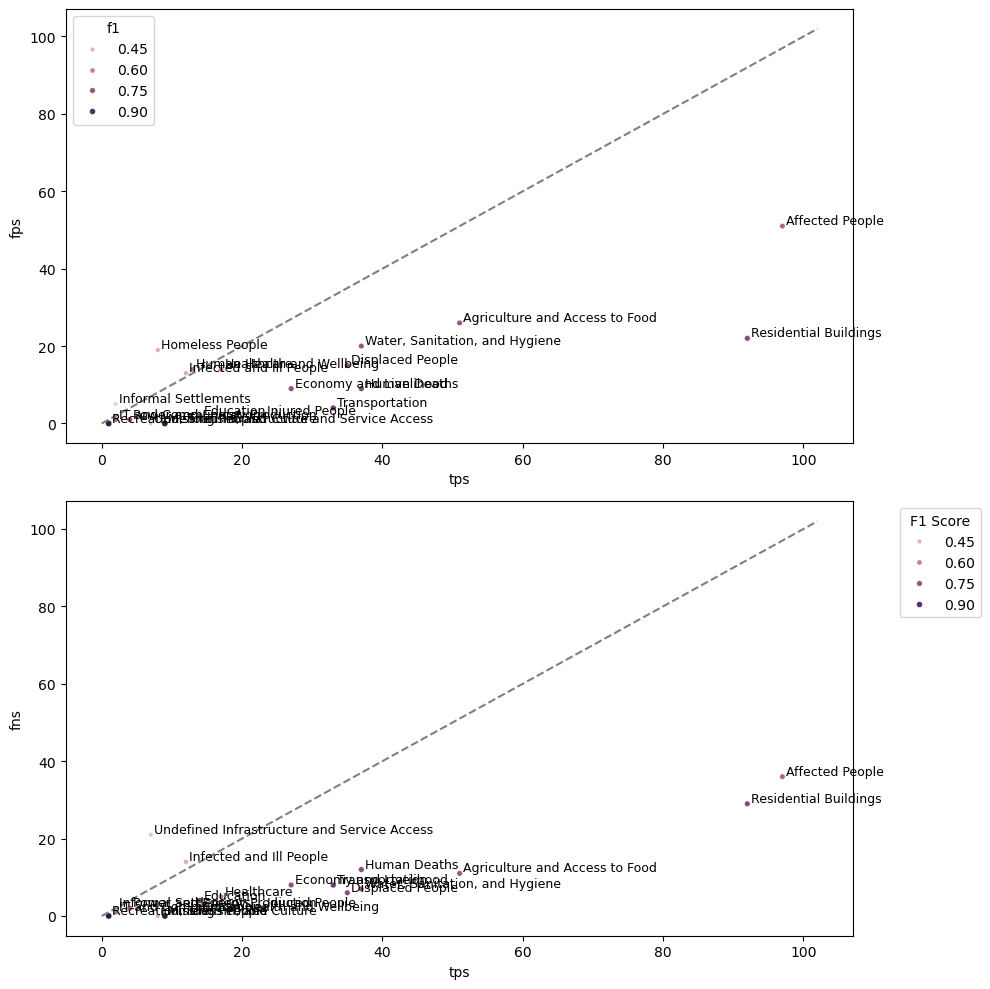

In [52]:
import seaborn as sns

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
xkey = "tps"
ykeys = ["fps", "fns"]
for i, ykey in enumerate(ykeys):
    ax = axes[i]

    sns.scatterplot(
        ax=ax,
        data=f1_bs_by_subtype,
        x=xkey,
        y=ykey,
        hue="f1",
        size="f1",
        sizes=(10, 20),
        legend=True,
    )
    # add impact subtype text
    for i, row in f1_bs_by_subtype.iterrows():
        ax.text(row[xkey]+0.5, row[ykey]+0.5, row["impactSubtype"], fontsize=9)

    # add 1-1 line
    max_val = max(f1_bs_by_subtype[xkey].max(), f1_bs_by_subtype[ykey].max()) + 5
    ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
    #ax.set_xlabel("Number of extracted impacts")
    #ax.set_ylabel("Number of labelled impacts")
    #ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

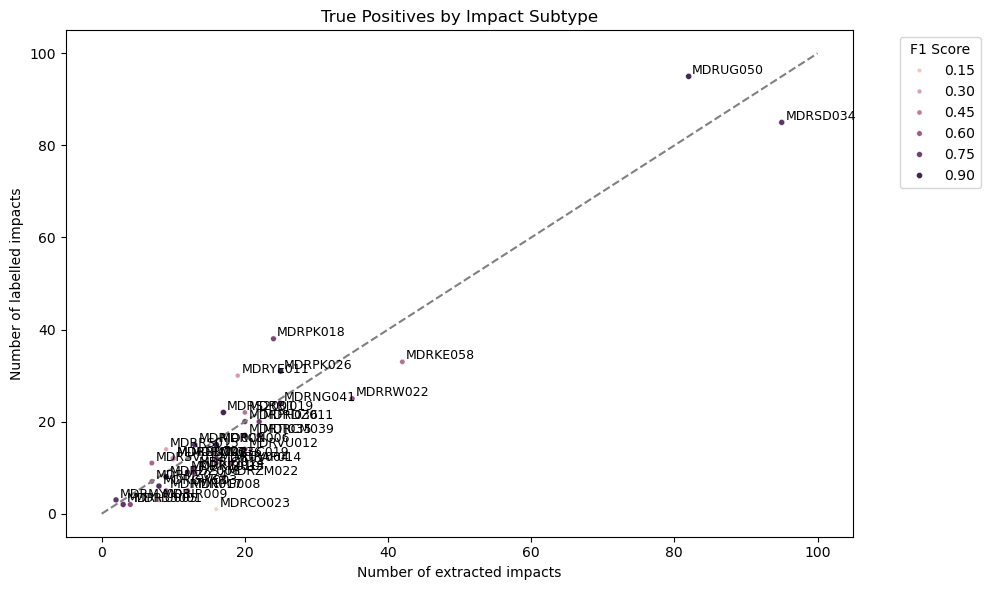

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="n_ext",
    y="n_lab",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["n_ext"] + 0.5, row["n_lab"] + 0.5, row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["n_ext"].max(), f1_bs_by_appeal["n_lab"].max()) + 5
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Number of extracted impacts")
ax.set_ylabel("Number of labelled impacts")
ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

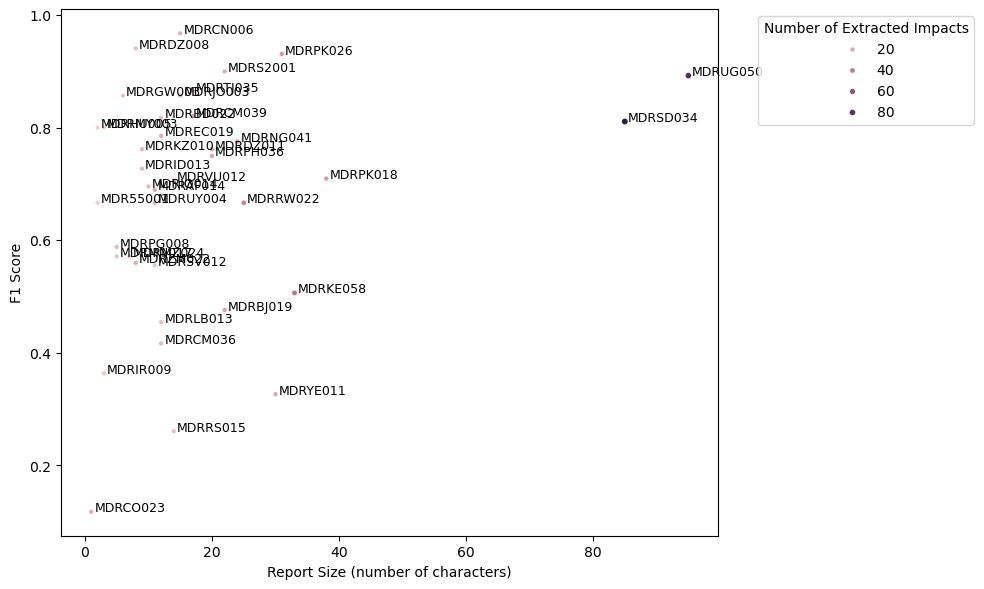

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey="n_lab"
ykey="f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
#max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
#ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
#ax.set_title("")
plt.legend(title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

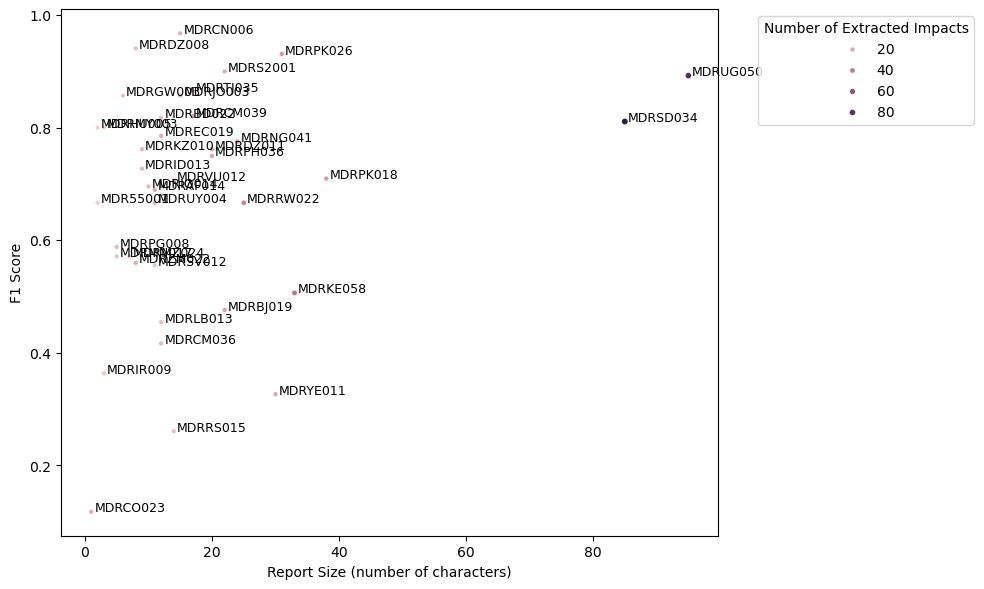

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "n_lab"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
# max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
# ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
# ax.set_title("")
plt.legend(
    title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

<Axes: xlabel='tps', ylabel='f1'>

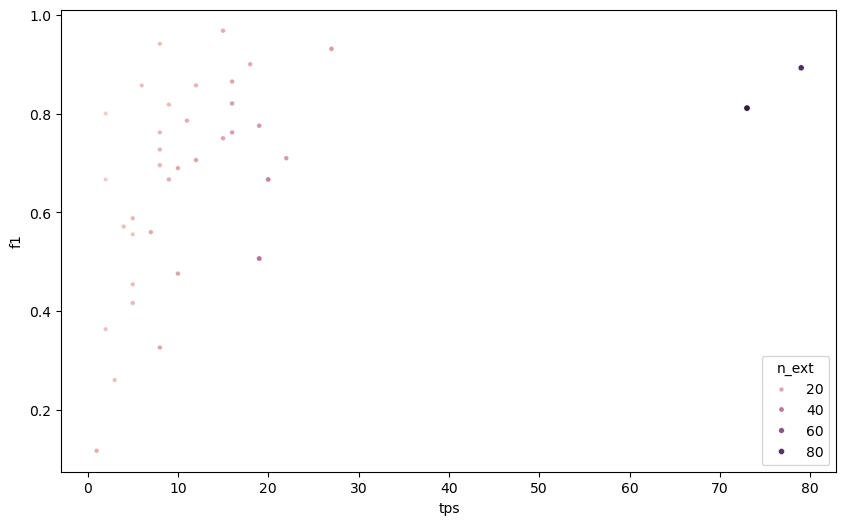

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "tps"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

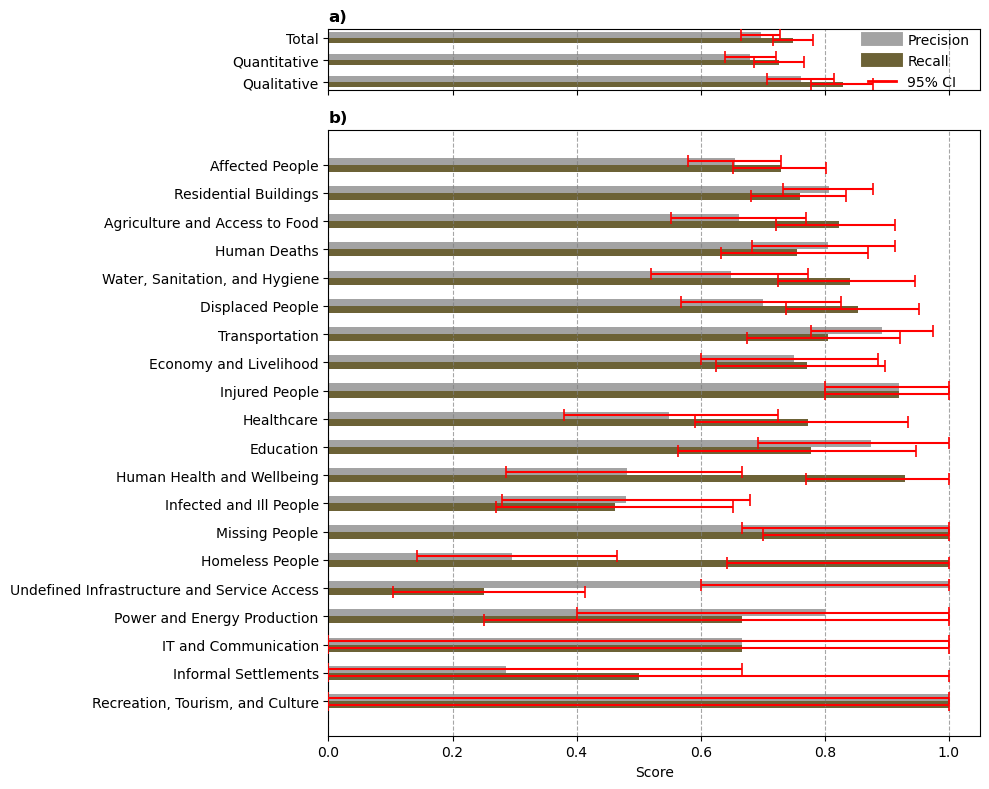

In [57]:

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    if isinstance(df, pd.Series):
        df = df.to_frame().T
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = np.atleast_1d(df[f"{metric}"])
        lower = np.atleast_1d(df[f"{metric}_low_err"])
        upper = np.atleast_1d(df[f"{metric}_high_err"])

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, -0.08), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax[1].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=600)

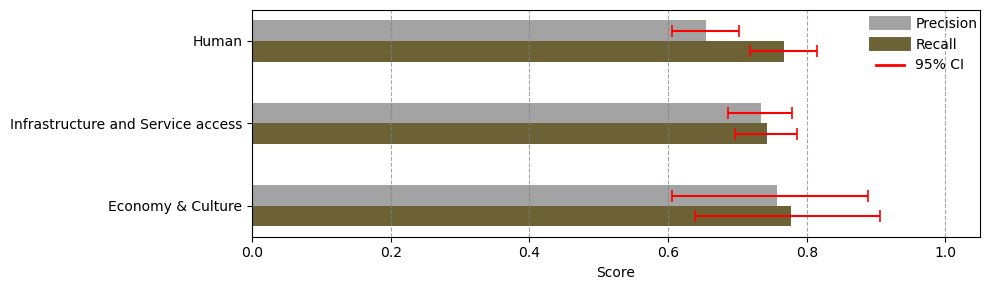

In [58]:
metrics = ["precision", "recall"]  # "f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactType"

data = f1_bs_by_maintype

fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), sharey=False, sharex=False#, height_ratios=[1, 10]
)
ax = [ax]  # make ax a list for compatibility with plotting function
# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], data, group_key, metrics, colors)

# --- Plot top panel (by-key metrics) ---
# plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[0].set_xlabel("Score")
ax[0].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D(
    [0], [0], color="red", lw=2, marker="_", markersize=10, label="95% CI"
)
bars_proxy = [
    Line2D([0], [0], color=c, lw=10, label=m.capitalize())
    for m, c in zip(metrics, colors)
]

# --- Add legend ---
# ax[1].get_legend().remove()
ax[0].legend(
    handles=bars_proxy + [err_proxy], loc=(0.85, 0.7), frameon=False
)  # title="Metrics"

# ax[0].set_title("a)", fontweight="bold", loc="left")
# ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)
# ax[1].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    DATA_FIGURE
    / f"precision_recall_maintypes_EGU26.png",
    bbox_inches="tight",
    dpi=600,
)

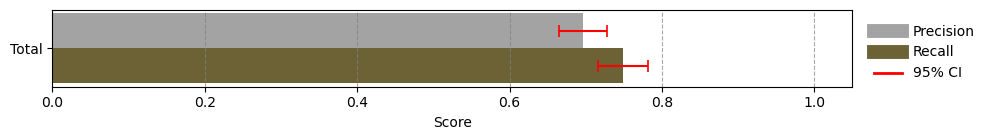

In [59]:
metrics = ["precision", "recall"]  # "f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "quanti"

data = f1_bs_all.set_index("quanti", drop=False).loc["Total"]

fig, ax = plt.subplots(
    1, 1, figsize=(10, 1.5), sharey=False, sharex=False  # , height_ratios=[1, 10]
)
ax = [ax]  # make ax a list for compatibility with plotting function
# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], data, group_key, metrics, colors)

# --- Plot top panel (by-key metrics) ---
# plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[0].set_xlabel("Score")
ax[0].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D(
    [0], [0], color="red", lw=2, marker="_", markersize=10, label="95% CI"
)
bars_proxy = [
    Line2D([0], [0], color=c, lw=10, label=m.capitalize())
    for m, c in zip(metrics, colors)
]

# --- Add legend ---
# ax[1].get_legend().remove()
ax[0].legend(
    handles=bars_proxy + [err_proxy], loc=(1.02, 0.01), frameon=False,
    ncol=1
)  # title="Metrics"

# ax[0].set_title("a)", fontweight="bold", loc="left")
# ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)
# ax[1].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    DATA_FIGURE / f"precision_recall_total_EGU26.png",
    bbox_inches="tight",
    dpi=600,
)

In [60]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Affected People,97,148,133,51,36,0.690391,0.655405,0.729323,0.063526,0.057908,0.076458,0.073627,0.076782,0.072203
8,Residential Buildings,92,114,121,22,29,0.782979,0.807018,0.760331,0.059764,0.054420,0.074875,0.071243,0.079667,0.074380
20,Agriculture and Access to Food,51,77,62,26,11,0.733813,0.662338,0.822581,0.087659,0.076998,0.111056,0.106893,0.101992,0.091212
5,Human Deaths,37,46,49,9,12,0.778947,0.804348,0.755102,0.097129,0.083798,0.122530,0.108696,0.122449,0.114463
16,"Water, Sanitation, and Hygiene",37,57,44,20,7,0.732673,0.649123,0.840909,0.109017,0.093015,0.129892,0.124462,0.115909,0.105037
2,Displaced People,35,50,41,15,6,0.769231,0.700000,0.853659,0.102564,0.087912,0.131373,0.126087,0.115563,0.098722
15,Transportation,33,37,41,4,8,0.846154,0.891892,0.804878,0.096154,0.069509,0.114114,0.082467,0.129878,0.116175
11,Economy and Livelihood,27,36,35,9,8,0.760563,0.750000,0.771429,0.114410,0.096579,0.150000,0.135714,0.146429,0.126007
1,Injured People,23,25,25,2,2,0.920000,0.920000,0.920000,0.093913,0.061132,0.120000,0.080000,0.120000,0.080000
17,Healthcare,17,31,22,14,5,0.641509,0.548387,0.772727,0.173424,0.138152,0.169185,0.175751,0.181818,0.160606


In [ ]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Total,526,469,371,155,98,0.745729,0.705323,0.791045,0.031002,0.029541,0.039315,0.037974,0.038263,0.035711
0,Quantitative,359,314,240,119,74,0.713224,0.668524,0.764331,0.043486,0.037136,0.051210,0.048143,0.048326,0.046394
0,Qualitative,167,155,131,36,24,0.813665,0.784431,0.845161,0.049911,0.046037,0.065133,0.061723,0.058495,0.056157


In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [ ]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Water, Sanitation, and Hygiene    7
Displaced People                  5
Affected People                   5
Homeless People                   4
Agriculture and Access to Food    4
Human Health and Wellbeing        4
Economy and Livelihood            3
Residential Buildings             2
Missing People                    2
Education                         2
Name: count, dtype: int64

In [ ]:
un_matched_quanti.impactSubtype.value_counts()

impactSubtype
Human Deaths                      2
Displaced People                  1
Agriculture and Access to Food    1
Transportation                    1
Name: count, dtype: int64

In [ ]:
un_matched.impactSubtype.value_counts()

impactSubtype
Water, Sanitation, and Hygiene    7
Displaced People                  6
Agriculture and Access to Food    5
Affected People                   5
Homeless People                   4
Human Health and Wellbeing        4
Economy and Livelihood            3
Residential Buildings             2
Missing People                    2
Education                         2
Human Deaths                      2
Transportation                    1
Name: count, dtype: int64

In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRYE011    10
MDRIQ014     8
MDRBD022     6
MDRPK026     6
MDRKE058     4
MDRSV012     3
MDRNG041     2
MDRSD034     2
MDRMY003     1
MDRS2001     1
Name: count, dtype: int64

In [ ]:
labelled_df_filter[labelled_df_filter["appealCode"] == "MDRZM022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
170,2024-04-02,Affected People,5000000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
171,2024-04-02,Agriculture and Access to Food,10000.0,km**2 of crop production and forestry,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
172,2024-04-02,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
173,2024-04-02,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
174,2024-04-02,Economy and Livelihood,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
175,2024-04-02,Agriculture and Access to Food,2040000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."
176,2024-04-02,Affected People,546139.0,people,exact,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['Kalabo district', 'Senanga district', 'Sikon...",...,0.0,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1..."
177,2024-04-02,Human Health and Wellbeing,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,0.0,"['North-Western Province', 'Southern Province'...","['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -..."


In [ ]:
extracted_df_filter[extracted_df_filter["appealCode"] == "MDRZM022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
511,Affected People,5000000.0,NaN,NaN,exact,people,"['People Affected: 5,000,000 people']",0,[],"['People Affected: 5,000,000 people']",...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
514,Affected People,5000000.0,NaN,NaN,exact,people,"['1 million households have been affected, and...",0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0]",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
515,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2 of crop production and forestry,['1 million hectors of maize field affected ou...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The current drought has affected 8 provinces...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
516,Agriculture and Access to Food,22000.0,NaN,NaN,exact,km**2,['1 million hectors of maize field affected ou...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713.0, 1720.0, 1717....","[nan, 106584.0, 106624.0, 106625.0, 106631.0, ...",NaN,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555
517,Agriculture and Access to Food,5000000.0,NaN,NaN,exact,people,['The whole Southern half of Zambia is experie...,0,"['The whole Southern half of Zambia', 'Zambia']",['The whole Southern half of Zambia is experie...,...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
518,Affected People,2040000.0,NaN,NaN,approx,people,['The situation has come at the time when the ...,0,[],['The situation has come at the time when the ...,...,['Zambia'],['Zambia'],['ZMB'],[168.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.74001 -8.34001, 31.15775 -8...",14555
519,Affected People,546139.0,NaN,NaN,exact,people,"['Among the most affected districts, Kalabo, S...",0,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Among the most affected districts, Kalabo, S...",...,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...","['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1...",14555
520,Affected People,247390.0,NaN,NaN,exact,people,"['Lunga, Milengi, Rufunsa, Lupososhi and Mwans...",0,"['Lunga', 'Milengi', 'Rufunsa', 'Lupososhi', '...","['Lunga, Milengi, Rufunsa, Lupososhi and Mwans...",...,"['Lunga District', 'Zambia', 'Rufunsa', 'Lupos...","['Luapula', 'Zambia', 'Rufunsa', 'Northern', '...",['ZMB'],[168.0],"[1714.0, nan, 1715.0, 1718.0, 1719.0]","[nan, 106585.0, 106575.0]",NaN,False,"MULTIPOLYGON (((29.37184 -8.72326, 29.37003 -8...",14555
521,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2,['One (1) million households (five (5) million...,0,"['Southern Province', 'Central', 'Eastern', 'N...",['The whole Southern half of Zambia is experie...,...,"['Southern Province', 'Central Province', 'Eas...","['Northern', 'Southern', 'Central', 'Eastern',...",['ZMB'],[168.0],"[1718.0, 1719.0, 1711.0, 1713

In [ ]:
un_matched[un_matched["appealCode"] == "MDRZM022"]["impactValue_sim"].max()

nan

In [ ]:
print_match(un_matched[un_matched["appealCode"]=="MDRRW022"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
un_matched[un_matched["impactSubtype"] == "Economy and Livelihood"][["location","location_matched","locationPolygon", "locationPolygon_matched", "locationOsm", "locationOsm_matched"]]

,location,location_matched,locationPolygon,locationPolygon_matched,locationOsm,locationOsm_matched
15,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Kurigram District', 'Gaibandha', 'Lalmonirha...","['Kurigram District', 'Gaibandha', 'Lalmonirha..."
16,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...","['Bangladesh', 'Gaibandha']","['Kurigram District', 'Gaibandha', 'Lalmonirha...","['Bangladesh', 'Lalmonirhat - Patgram Hwy']"
279,"['coastal area', 'Clarendon', 'St. Elizabeth',...",[],"['Clarendon', 'Jamaica', 'Saint Joseph', 'Chri...",['Jamaica'],"['Clarendon', 'Jamaica', 'St. Elizabeths', 'Ma...",['Jamaica']


In [ ]:
print_match(un_matched[un_matched["impactSubtype"]=="Economy and Livelihood"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Economy and Livelihood,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.472222,['While the monsoon season normally brings ann...,['It is also reported that embankments have be...
16,MDRBD022,Economy and Livelihood,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']","['Rangpur', 'Gaibandha', 'Chittagong', 'Rangam...",...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.341982,['While the monsoon season normally brings ann...,['of union affected 776 Emergency Plan of Acti...
279,MDRS2001,Economy and Livelihood,Infected and Ill People,NaN,NaN,null,null,"['coastal area', 'Clarendon', 'St. Elizabeth',...",[],"['Clarendon', 'Jamaica', 'Saint Joseph', 'Chri...",...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.495630,['The economic toll of Hurricane Beryl is subs...,"['This displacement, combined with damaged wat..."


In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRYE011    10
MDRIQ014     8
MDRBD022     6
MDRPK026     6
MDRKE058     4
MDRSV012     3
MDRNG041     2
MDRSD034     2
MDRMY003     1
MDRS2001     1
Name: count, dtype: int64

In [ ]:
labelled_df[labelled_df["appealCode"] == "MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry
450,2024-09-05,Affected People,60000.0,people,exact,NaN,NaN,['DREF Final Report Rwanda - Floods and Landsl...,['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
451,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
452,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
453,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
454,2024-09-05,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
455,2024-09-05,Transportation,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
456,2024-09-05,Agriculture and Access to Food,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
457,2024-09-05,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
458,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,0.0,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1...."
459,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,6.0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",['Iburengerazuba'],['RWA'],[152.0],[1557.0],[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1..."


In [ ]:
extracted_df[extracted_df["appealCode"] == "MDRRW022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,reportSize
268,Affected People,60000.000000,NaN,NaN,exact,people,"['People Affected: 60,000 people']",0,"['North Province', 'South Province', 'West Pro...","['People Affected: 60,000 people']",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
269,Targeted People,49485.000000,NaN,NaN,exact,people,"['People Targeted: 49,485 people']",0,"['North Province', 'South Province', 'West Pro...","['Targeted Areas: North Province, South Provin...",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
270,DREF Allocation & Funding requirements,532435.569755,NaN,NaN,exact,EUR,"['Total DREF Allocation: CHF 499,957']",0,[],"['Total DREF Allocation: CHF 499,957']",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
271,Affected People,51905.000000,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['Western Province', 'Northern Province', 'Sou...","['Overall, 14 districts experienced flooding a...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
272,Human Deaths,137.000000,NaN,NaN,exact,people,"['A total of 137 people died, and 5,472 houses...",0,[],"['A total of 137 people died, and 5,472 houses...",...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
273,Homeless People,51905.000000,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['Western Province', 'Northern Province', 'Sou...","['From 1 to 6 May, Rwanda experienced continuo...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
274,Displaced People,51905.000000,NaN,NaN,exact,people,['Those affected were gathered together in IDP...,0,"['Western Province', 'Northern Province', 'Sou...",['According to assessments carried out by the ...,...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
275,Residential Buildings,5472.000000,NaN,NaN,exact,homes,"['A total of 137 people died, and 5,472 houses...",0,"['Western Province', 'Northern Province', 'Sou...","['From 1 to 6 May, Rwanda experienced continuo...",...,"['Western Province', 'Northern Province', 'Sou...","['Iburengerazuba', 'Amajyaruguru', 'Amajyepfo']",['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]",[nan],NaN,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484
276,Displaced People,38000.000000,NaN,NaN,exact,people,['Information reported by branches on 3rd stat...,0,[],['Information reported by branches on 3rd stat...,...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484
277,Homeless People,38420.000000,NaN,NaN,exact,people,['Information reported by branches on 3rd stat...,0,[],['Information reported by branches on 3rd stat...,...,['Rwanda'],['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484


In [ ]:
cat = "Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,true_positives,false_negatives,false_positives,precision,recall,f1,quanti
0,Healthcare,7,9,128.571429,7,0,2,0.777778,1.0,0.875000,quanti
1,Healthcare,7,10,142.857143,7,0,3,0.700000,1.0,0.823529,quali


In [ ]:
print_match(m_df2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
130,MDRKE058,Healthcare,Healthcare,7.0,7.0,healthcare structures,healthcare structures,[],"['Lake Victoria Basin', 'Highlands West of the...",['Kenya'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.577350,0.930685,['The economic activities of the areas have be...,['October November December short rains season...
136,MDRKE058,Healthcare,Healthcare,59.0,59.0,healthcare structures,healthcare structures,[],[],['Kenya'],...,1.0,1.0,1.0,0.0,0.0,1.0,0.707107,0.962123,['Health facilities 59 7'],['October November December short rains season...
238,MDRRW022,Healthcare,Healthcare,8.0,8.0,healthcare structures,healthcare structures,[],[],['Rwanda'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.935807,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."
242,MDRRW022,Healthcare,Healthcare,14.0,14.0,healthcare structures,healthcare structures,['Rutsiro'],['Rutsiro'],['Iburengerazuba'],...,1.0,1.0,0.0,0.0,0.0,0.0,0.707107,0.935807,"['Additionlly,14 health centres in Rutsiro wer...","['From 1 to 6 May, Rwanda experienced continuo..."
284,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],['Sudan'],...,0.0,0.0,1.0,0.0,0.0,1.0,0.577350,0.904369,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
351,MDRSD034,Healthcare,Healthcare,1.0,1.0,healthcare structures,healthcare structures,"['Tokar city, Red Sea State']",['Tokar'],['Sudan'],...,1.0,1.0,1.0,0.0,1.0,1.0,0.707107,0.896722,['The city’s hospital has been severely affect...,"['- In Tokar city, Red Sea State, the situatio..."
437,MDRUG050,Healthcare,Healthcare,3.0,3.0,healthcare structures,healthcare structures,"['Bukedea district', 'Kolir Sub County']",['Kolir Sub County'],"['Bukedea', 'Eastern']",...,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.883810,['This resulted in the destruction of three he...,"['Following heavy rainfall, a rise in the wate..."
205,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Badin', 'Sohbatpur', 'Chitral']",[],"['Badin', 'Sohbatpur', 'Chitral Lower', 'Chitr...",...,1.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.615474,"['Additionally, the stagnant water in low-lyin...","['Additionally, the stagnant water in low-lyin..."
206,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Badin', 'Sohbatpur', 'Chitral']","['Badin', 'Sindh']","['Badin', 'Sohbatpur', 'Chitral Lower', 'Chitr...",...,1.0,0.0,1.0,0.0,0.0,0.0,1.000000,0.702423,"['Additionally, the stagnant water in low-lyin...","['In response, PRCS successfully deployed a Mo..."
249,MDRRW022,Healthcare,Healthcare,NaN,NaN,null,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Nyarugenge', 'Rwanda', 'Ny...",...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.941749,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Displaced People                  12
Homeless People                   10
Affected People                    9
Water, Sanitation, and Hygiene     9
Agriculture and Access to Food     5
Human Health and Wellbeing         5
Economy and Livelihood             4
Human Deaths                       3
Residential Buildings              3
Education                          2
Missing People                     2
Infected and Ill People            1
Injured People                     1
Transportation                     1
Name: count, dtype: int64

In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Affected People
impactSubtype_matched
Undefined Infrastructure and Service Access    3
Human Deaths                                   1
Injured People                                 1
Name: count, dtype: int64
Agriculture and Access to Food
impactSubtype_matched
Economy and Livelihood                         1
Residential Buildings                          1
Transportation                                 1
Undefined Infrastructure and Service Access    1
Name: count, dtype: int64
Displaced People
impactSubtype_matched
Undefined Infrastructure and Service Access    4
Transportation                                 1
Name: count, dtype: int64
Economy and Livelihood
impactSubtype_matched
Undefined Infrastructure and Service Access    2
Infected and Ill People                        1
Name: count, dtype: int64
Education
impactSubtype_matched
Transportation                                 1
Undefined Infrastructure and Service Access    1
Name: count, dtype: int64
Homeless People
impactSubt

In [ ]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

NameError: name 'IMPACT_SUBTYPES' is not defined

In [ ]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [ ]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [ ]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [ ]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [ ]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

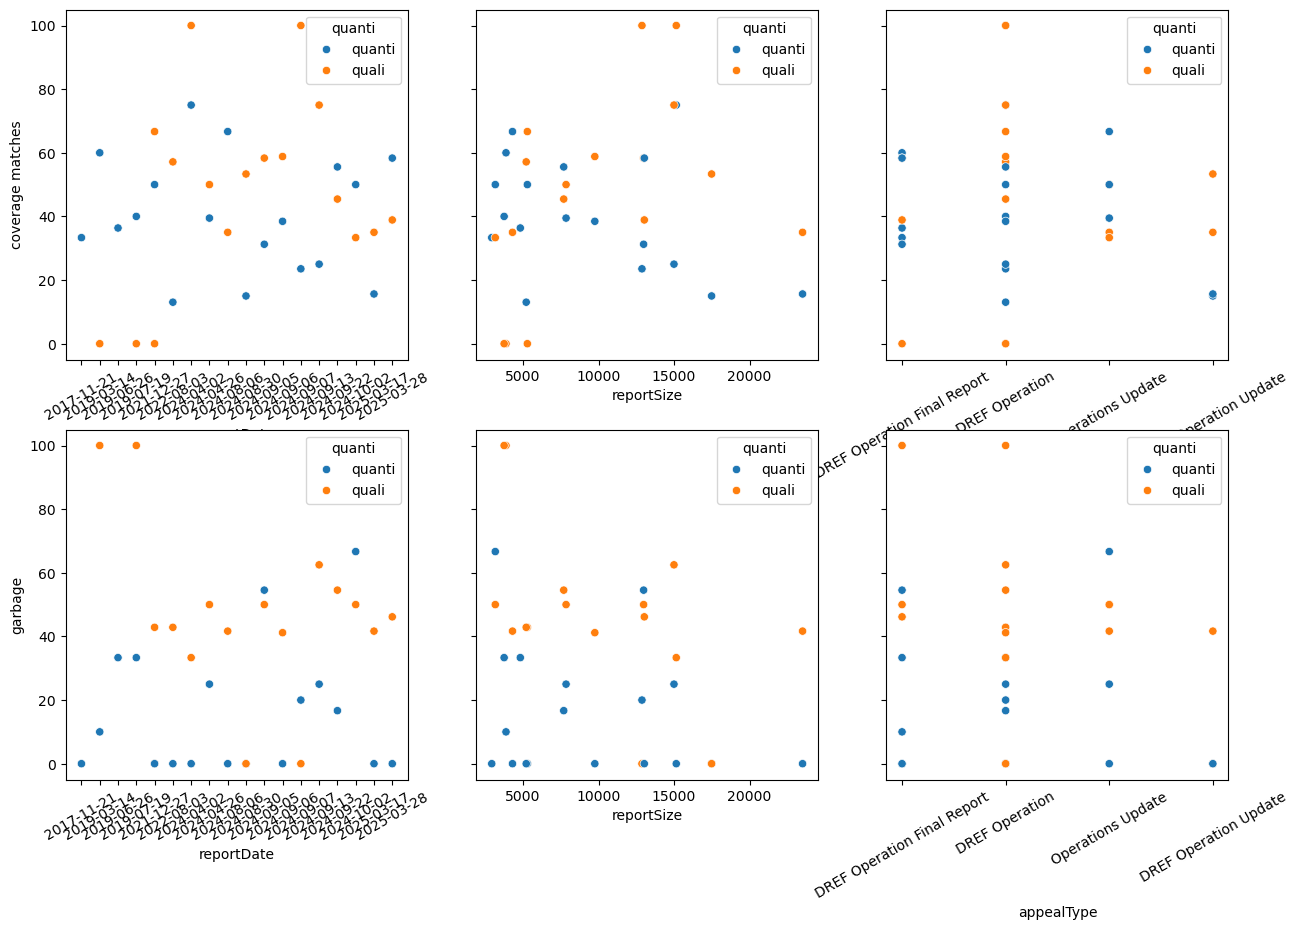

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

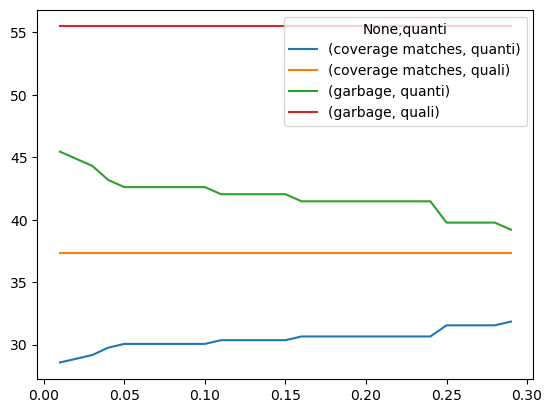

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

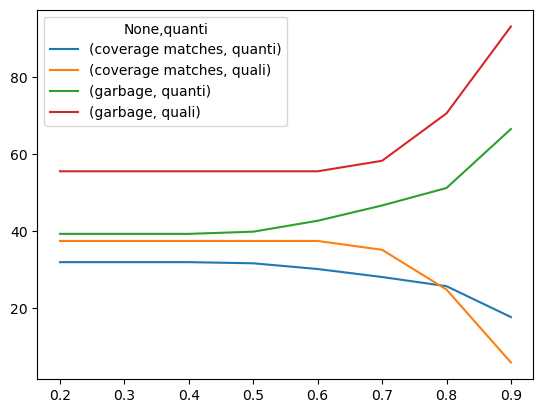

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [ ]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


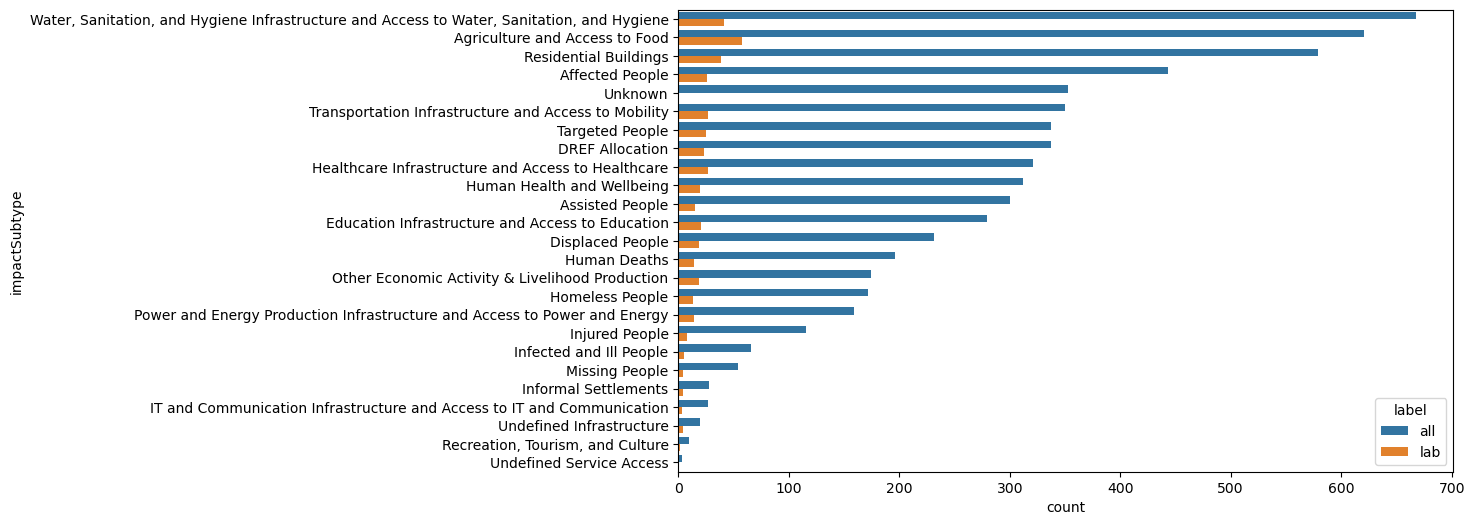

In [ ]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
